## Imports

In [1]:
from keras import layers, optimizers, Input, Model, callbacks, regularizers, metrics
from methods.load_data import load_ucsf
from methods.visualisation import plot_training_history, plot_segmentation_prediction

IMAGE_SIZE = 128

c:\Users\GGPC\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading dataset...
dataset loaded.
No data leakage of patient ids in train, validation and test splits


## Get dataset

In [2]:
x_train, y_train, x_val, y_val, x_test, y_test = load_ucsf(debug=False, classification=False, basic_mask=True, image_size=IMAGE_SIZE)
print(f"Training shape: x_train - {x_train.shape}, y_train - {y_train.shape}")
print(f"Validation shape: x_val - {x_val.shape}, y_val - {y_val.shape}")
print(f"Testing shape: x_test - {x_test.shape}, y_test - {y_test.shape}")

loading dataset...
dataset loaded.
No data leakage of patient ids in train, validation and test splits
Training shape: x_train - (18411, 128, 128, 3), y_train - (18411, 128, 128, 1)
Validation shape: x_val - (7505, 128, 128, 3), y_val - (7505, 128, 128, 1)
Testing shape: x_test - (5022, 128, 128, 3), y_test - (5022, 128, 128, 1)


## Construct model

In [3]:
def conv2D_layer(filter_size, x, strides=1):
    return layers.Conv2D(filter_size, (3, 3), strides=strides, activation="relu", padding="same", kernel_regularizer=regulariser)(x)

def batch_norm_layer(x):
    return layers.BatchNormalization()(x)

def conv2D_transpose_layer(filter_size, x):
    return layers.Conv2DTranspose(filter_size, (3, 3), strides=2, activation="relu", padding="same", kernel_regularizer=regulariser)(x)

regulariser = regularizers.l2(1e-4)
inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

# Encoding
e1 = conv2D_layer(16, inputs)
e1 = batch_norm_layer(e1)
e2 = conv2D_layer(32, e1, strides=2)
e2 = batch_norm_layer(e2)
e3 = conv2D_layer(64, e2, strides=2)
e3 = batch_norm_layer(e3)

# Bottleneck
b = conv2D_layer(128, e3)
b = layers.Dropout(0.3)(b)

# Decoder
d3 = conv2D_transpose_layer(64, b)
d3 = layers.Concatenate()([d3, e2])
d3 = conv2D_layer(64, d3)
d2 = conv2D_transpose_layer(32, d3)
d2 = layers.Concatenate()([d2, e1])
d2 = conv2D_layer(32, d2)
d1 = conv2D_layer(16, d2)
output = layers.Conv2D(1, (1, 1), activation="sigmoid", padding="same")(d1)

model = Model(inputs=inputs, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      4,640 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     73,856 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │     73,792 │ dropout[0][0]     │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 96)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     55,360 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 128, 128,  │     18,464 │ conv2d_4[0][0]    │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 48)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │     13,856 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │      4,624 │ conv2d_5[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │         17 │ conv2d_6[0][0]  

 Total params: 264,001 (1.01 MB)

 Trainable params: 263,777 (1.01 MB)

 Non-trainable params: 224 (896.00 B)

## Compile model

In [4]:
IoU = metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[IoU]
)

## Fit model

In [5]:
BATCH_SIZE = 32
EPOCHS = 30

def get_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        ),
        callbacks.ModelCheckpoint(
            filepath="models/best_segmentation_model.keras",
            monitor="val_binary_io_u",
            save_best_only=True,
            mode="max"
        )
    ]
    
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    callbacks=get_callbacks(),
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 428s 738ms/step - binary_io_u: 0.4655 - loss: 0.0968 - val_binary_io_u: 0.6203 - val_loss: 0.0704
Epoch 2/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 422s 733ms/step - binary_io_u: 0.6323 - loss: 0.0596 - val_binary_io_u: 0.6832 - val_loss: 0.0543
Epoch 3/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 422s 732ms/step - binary_io_u: 0.6783 - loss: 0.0511 - val_binary_io_u: 0.6890 - val_loss: 0.0491
Epoch 4/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 428s 743ms/step - binary_io_u: 0.7059 - loss: 0.0455 - val_binary_io_u: 0.7194 - val_loss: 0.0447
Epoch 5/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 435s 756ms/step - binary_io_u: 0.7231 - loss: 0.0416 - val_binary_io_u: 0.7248 - val_loss: 0.0406
Epoch 6/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 428s 743ms/step - binary_io_u: 0.7369 - loss: 0.0385 - val_binary_io_u: 0.7412 - val_loss: 0.0374
Epoch 7/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 435s 755ms/step - binary_io_u: 0.7473 - loss: 0.0361 - val_binary_io_u: 0.7542 - val_loss: 0.0357
Epoch 8/30
576/576 ━━━━━━━━━━━━━━━

## Plot training and validation history

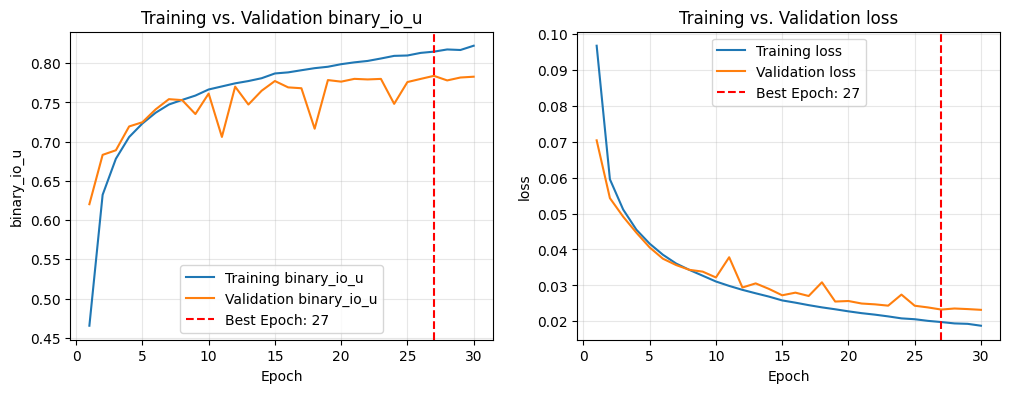

In [6]:
plot_training_history(history, "binary_io_u", "loss")

## Evaluate model

157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step - binary_io_u: 0.7627 - loss: 0.0248
Test IoU: 0.7627, Test Loss: 0.0248
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


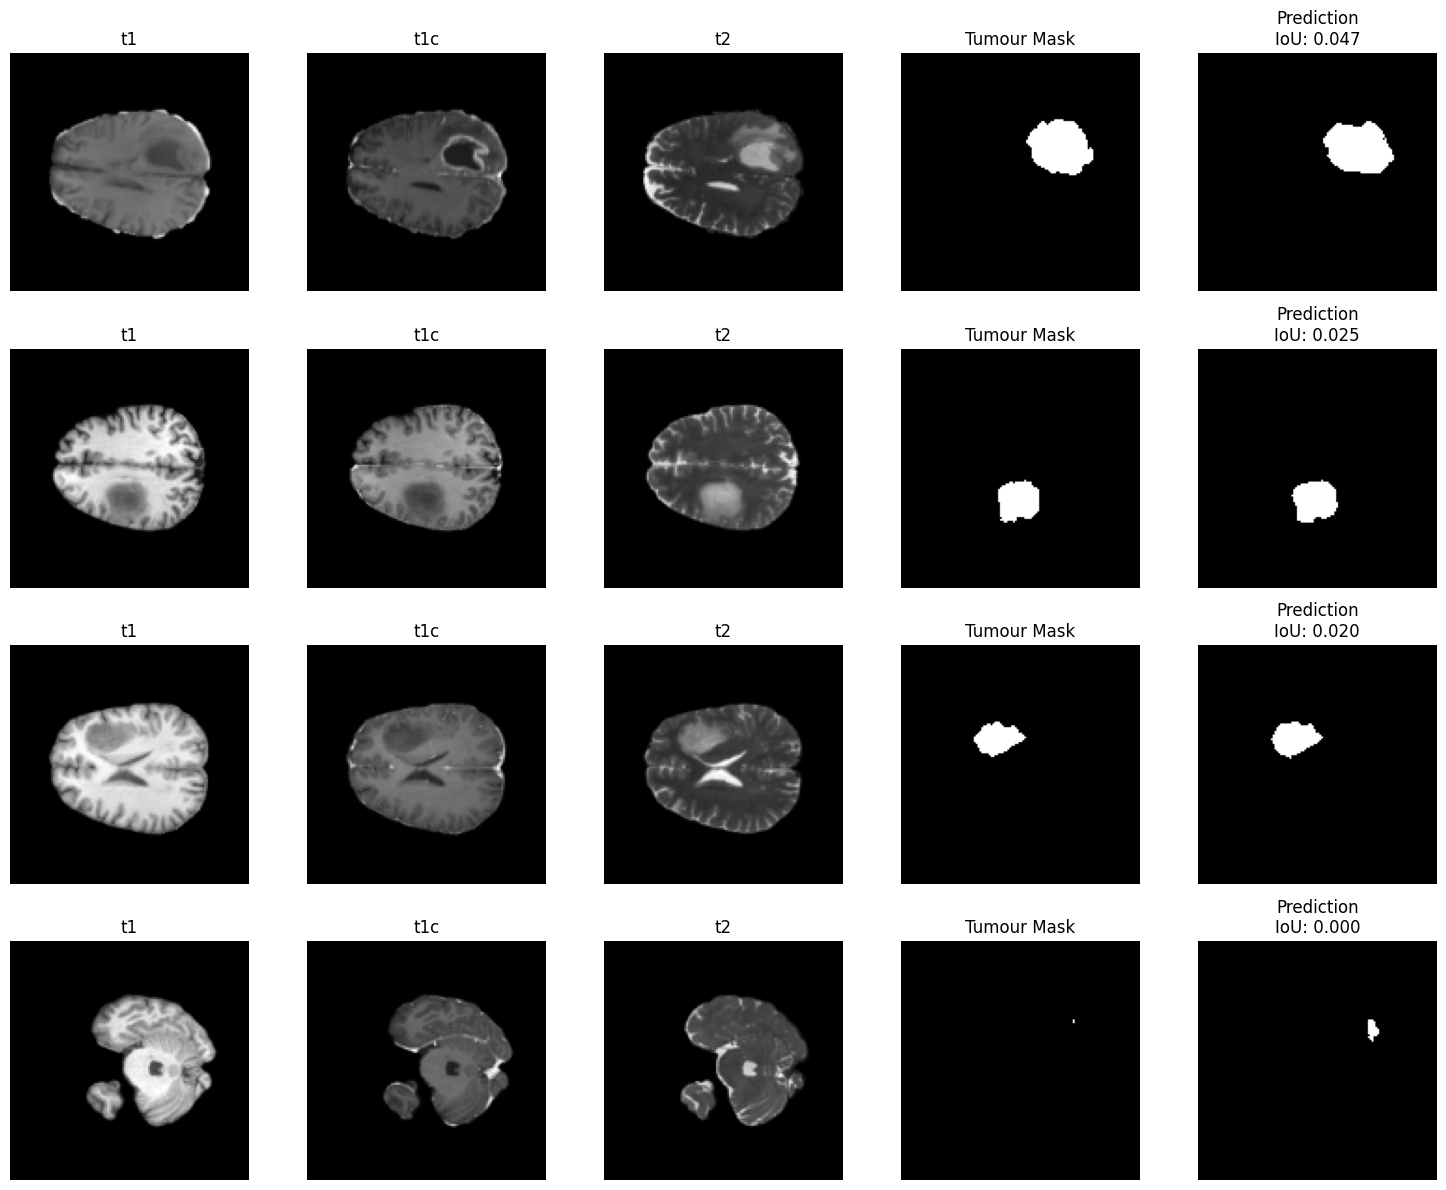

In [ ]:
loss, iou = model.evaluate(x_test, y_test)
print(f"Test IoU: {iou:.4f}, Test Loss: {loss:.4f}")
plot_segmentation_prediction(x_test, y_test, model, 4)

## Notes

Plateaus around 66% IoU accuracy for validation on debug. 78% of full data